<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [ ]:
!pip install -q chromadb ragatouille

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.4 MB/s eta 

In [ ]:
!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl datasets langchain-community ragatouille umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2

In [ ]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel

#------------------------------------------------------------------------------------
from langchain.text_splitter import TokenTextSplitter# выберите другую стратегию разбивки на чанки = TokenTextSplitter

pd.set_option("display.max_colwidth", None)

/tmp/ipython-input-2974165176.py:17: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


## Загрузка данных (4 балла)

In [ ]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=6517cabb-9561-4146-86fa-ba2a5e0765b5
To: /content/file.csv
100%|██████████| 672M/672M [00:13<00:00, 49.7MB/s]


In [ ]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,...,there are two people that are standing on a track in a stadium
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,...,arafed building with a blue and white exterior and a blue fence
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,...,there is a blue and white building with a clock on top
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,...,there is a blue and white building with a clock on top
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,...,there is a boat that is in the water near a building


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [ ]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [ ]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

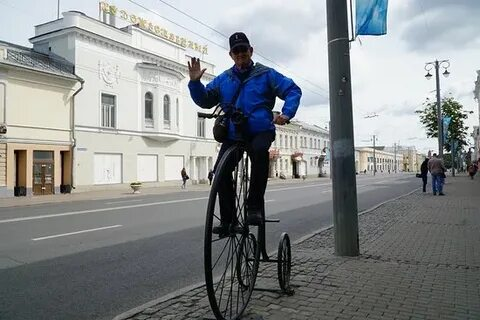

In [ ]:
get_image(data.sample(1)['image'].tolist()[0])

##1. EDA
Посмотреть и исследовать:
сколько уникальных памятников
сколько изображений на памятник
распределение по городам
географическое распределение (карта!)
качество изображений (можно через CLIP score или простую резкость)
длина текстов (описание, BLIP-описание)
дубликаты: текстовые vs визуальные

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   14634 non-null  int64  
 1   Name         14634 non-null  object 
 2   WikiData     12078 non-null  object 
 3   City         14634 non-null  object 
 4   Lon          14634 non-null  float64
 5   Lat          14634 non-null  float64
 6   description  12078 non-null  object 
 7   image        14634 non-null  object 
 8   en_txt       14634 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 1.0+ MB


In [ ]:
data["Name"].value_counts().head(20)

,count
Name,
Владимир,114
улица Добролюбова,87
Кресень,86
Чкаловская лестница,82
Театр оперы и балета,78
Церковь Рождества Христова,71
Театр кукол,70
Белая башня,69
улица Февральской Революции,62


In [ ]:
data["description"] = data["description"].fillna("")
data["image"] = data["image"].fillna("")

<Axes: >

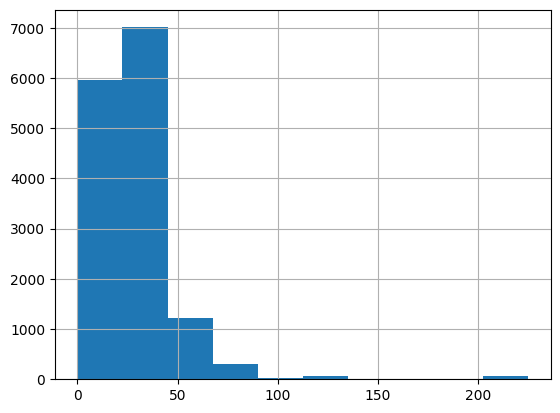

In [ ]:
data["description"].str.len().hist()

In [ ]:
# Количество достопримечательностей
len(data["Name"].value_counts())

387

In [ ]:
# Количество городов = 4
data["City"].value_counts()

,count
City,
Ярославль,4372
Владимир,3511
Нижний Новгород,3469
Екатеринбург,3282


В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Берём текстовый корпус
data["full_text"] = data["description"].fillna("")

texts = data["full_text"].tolist()

# 2. Строим TF-IDF
vectorizer = TfidfVectorizer(
    max_features=20000,
    min_df=1,        # игнорируем совсем уникальные слова
    max_df=0.95,      # игнорируем слишком частые, типа "the", "and"
    ngram_range=(1, 2)  # можно и бигираммы
)
X = vectorizer.fit_transform(texts)

vocab = vectorizer.get_feature_names_out()
idf = vectorizer.idf_

idf_df = pd.DataFrame({"token": vocab, "idf": idf}).sort_values("idf", ascending=False)
idf_df.head(10)

,token,idf
253,дом болконского,7.295334
872,тимерёвский археологический,7.295334
83,болконского,7.295334
871,тимерёвский,7.295334
36,археологический комплекс,7.295334
414,княгинин,7.258967
364,института,7.258967
363,инженеров водного,7.258967
362,инженеров,7.258967
358,имени глинки,7.258967


In [ ]:
group_cols = ["City", "Name"]
grouped = data.groupby(group_cols, group_keys=False)

# Сколько брать сэмплов с каждой группы
# Например, по 3 записи на (город, место)
def sample_group(g, n=3):
    if len(g) <= n:
        return g
    return g.sample(n=n, random_state=42)

sampled = grouped.apply(sample_group)

print(len(sampled))

1173


/tmp/ipython-input-361150489.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = grouped.apply(sample_group)


In [ ]:
final_sample = sampled.sample(500, random_state=42)  # если нужно ровно 100
final_sample

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt,full_text
2851,3077,Усадьба Тарасова,Q4477575,Екатеринбург,60.606667,56.839722,Усадьба Тарасова,...,arafed building with a clock tower and a red door,Усадьба Тарасова
9195,2699,Пожарный автомобиль-лестница,NaN,Владимир,40.400349,56.126213,,...,there is a fire truck that is driving down the street,
12699,2437,Российский государственный академический театр драмы имени Федора Волкова,Q4398052,Ярославль,39.884796,57.627155,Российский академический театр драмы им. Ф. Волкова,...,arafed view of a large yellow building with a green roof,Российский академический театр драмы им. Ф. Волкова
11741,1479,М.В. Фрунзе,Q4343266,Ярославль,39.874001,57.599037,Памятник Михаилу Фрунзе (Ярославль),...,arafed apartment building with snow on the ground and a person walking in front,Памятник Михаилу Фрунзе (Ярославль)
8326,1629,"Музей науки и человека ЭВРИКА, г. Владимир",NaN,Владимир,40.400223,56.127617,,...,there is a young boy sitting at a table with a plate of food,
...,...,...,...,...,...,...,...,...,...,...
2600,2826,Екатеринбургский завод,Q4174314,Екатеринбург,60.605770,56.836639,металлургический завод (XVIII век),...,arafed factory with smoke billowing out of it's stacks,металлургический завод (XVIII век)
11652,1390,Леонтьевское кладбище,Q30709938,Ярославль,39.834396,57.629993,кладбище в Ярославле,...,people walking past a memorial with flowers and a statue,кладбище в Ярославле
7564,813,Здание городской думы,Q21639718,Владимир,40.406441,56.128639,Здание городской думы,...,there is a large red building with a clock tower on top,Здание городской думы
5619,2473,Пороховая башня,Q51946190,Нижний Новгород,44.007252,56.328491,круглая башня Нижегородского кремля,...,there is a tall brick tower with a green roof,круглая башня Нижегородского кремля


In [ ]:
def pick_longest_description(group):
    # group — это строки одного (city, name) или одного wikidata_id
    idx = group["description"].fillna("").str.len().idxmax()
    return group.loc[idx]

best_rows = final_sample.groupby(group_cols, group_keys=False).apply(pick_longest_description)

best_rows.reset_index(drop=True, inplace=True)
best_rows

/tmp/ipython-input-1905337332.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_rows = final_sample.groupby(group_cols, group_keys=False).apply(pick_longest_description)


Unnamed: 0                                                   Name  \
0          2154                                              1941-1945   
1          3391                          2000 летию Рождества Христова   
2          1008                          église arménienne de Vladimir   
3            72                               Авиамеханический колледж   
4          3053                                               Аптекарь   
..          ...                                                    ...   
307        4179                             Ярославский камерный театр   
308        4291  Ярославский художественный музей (Губернаторский дом)   
309        3376                     церковь Иоанна Предтечи в Толчкове   
310        3541                             церковь Николая Чудотворца   
311        3686                               церковь Николы Рублёного   

      WikiData       City        Lon        Lat  \
0          NaN   Владимир  40.362949  56.111187   
1          NaN   Владимир  40.408882  56.127674   
2    Q18331756   Владимир  40.456497  56.154667   
3    Q18786015   Владимир  40.387318  56.126278   
4          NaN   Владимир  40.402309  56.127251   
..         ...        ...        ...        ...   
307   Q4538885  Ярославль  39.881100  57.629101   
308   Q3329597  Ярославль  39.897274  57.628376   
309   Q2084804  Ярославль  39.856861  57.610909   
310  Q30913942  Ярославль  39.870548  57.620068   
311  Q16715656  Ярославль  39.898258  57.622509   

                                description  \
0                                             
1                                             
2    Армянская церковь в г. Владимир России   
3     Владимирский авиамеханический колледж   
4                                             
..                                      ...   
307              Ярославский камерный театр   
308        художественный музей в Ярославле   
309           Православный храм в Ярославле   
310           Православный храм в Ярославле   
311                        храм в Ярославле   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [ ]:
df = best_rows.copy()

for col in ["description", "en_txt"]:
        if col in df.columns:
            df[col] = df[col].fillna("")
        else:
            df[col] = ""

In [ ]:
def build_rag_text(row):
    text = f"""
Название: {row['Name']}
Город: {row['City']}
Координаты: {row['Lat']}, {row['Lon']}

Описание:
{row['description']}

BLIP описание изображения:
{row['en_txt']}
"""
    return text.strip()

best_rows["rag_text"] = best_rows.apply(build_rag_text, axis=1)

In [ ]:
# создаём словарь: (City, Name) -> все изображения
group_cols = ["City", "Name"]
all_images = (
    data.groupby(group_cols)["image"]
    .apply(list)
    .to_dict()
)

all_blip = (
    data.groupby(group_cols)["en_txt"]
    .apply(list)
    .to_dict()
)

In [ ]:
def build_rag_text(row):
        parts = [
            f"Название: {row.get('Name', '')}",
            f"Город: {row.get('City', '')}",
            f"Координаты: {row.get('Lat', '')}, {row.get('Lon', '')}",
        ]

        desc = (row.get("description", "") or "").strip()
        if desc:
            parts.append(f"Описание: {desc}")

        blip = (row.get("en_txt", "") or "").strip()
        if blip:
            parts.append(f"Описание изображения: {blip}")

        return "\n\n".join(parts).strip()

df["rag_text"] = df.apply(build_rag_text, axis=1)

In [ ]:
from langchain_core.documents import Document

In [ ]:
docs: List[Document] = []
for _, row in df.iterrows():
        metadata = {
            "name": row.get("Name"),
            "city": row.get("City"),
            "wikidata": row.get("WikiData"),
            "lat": float(row.get("Lat")) if pd.notna(row.get("Lat")) else None,
            "lon": float(row.get("Lon")) if pd.notna(row.get("Lon")) else None,
        }

        docs.append(
            Document(
                page_content=row["rag_text"],
                metadata=metadata,
            )
        )

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [ ]:
from langchain_text_splitters import TokenTextSplitter

# Чанкируем текст


splitter = TokenTextSplitter(
        chunk_size=512,
        chunk_overlap=64,
        model_name="gpt2",   # только для подсчёта токенов, эмбеддинги — отдельно
    )
chunked_docs = splitter.split_documents(docs)
print(f"Объектов: {len(docs)} → чанков: {len(chunked_docs)}")

Объектов: 312 → чанков: 312


In [ ]:
doc = chunked_docs[100]
doc.metadata

{'name': 'Дом-музей Бажова',
 'city': 'Екатеринбург',
 'wikidata': 'Q4290214',
 'lat': 56.818394,
 'lon': 60.613415}

In [ ]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# Создаём эмбеддинги
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

/tmp/ipython-input-771781097.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Создаём векторную базу
vectorstore = Chroma.from_documents(
        documents=chunked_docs,
        embedding=embeddings,
        collection_name='tourism_rag'
    )

In [ ]:
from ragatouille import RAGPretrainedModel

# Инициализируем ragatouille (ColBERT reranker)
reranker = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


In [ ]:
from langchain_core.documents import Document
from typing import List

def retrieve_and_rerank(
    query: str,
    vectorstore: Chroma,
    reranker: RAGPretrainedModel,
    k_retriever: int = 20,
    k_rerank: int = 5,
) -> List[Document]:
    """
    1) достаём k_retriever чанков из векторки
    2) ранжируем их через ragatouille (ColBERT)
    3) возвращаем отсортированный top-k_rerank список Document
    """
    retriever = vectorstore.as_retriever(search_kwargs={"k": k_retriever})
    initial_docs = retriever.get_relevant_documents(query)

    if not initial_docs:
        return []

    passages = [doc.page_content for doc in initial_docs]
    reranked = reranker.rerank(
        query=query,
        documents=passages,
        k=k_rerank,
    )
    text_to_doc = {doc.page_content: doc for doc in initial_docs}

    ordered_docs = [
        text_to_doc[item["content"]]
        for item in reranked
        if item["content"] in text_to_doc
    ]
    return ordered_docs

In [ ]:
def build_context(docs: List[Document]) -> str:
    parts = []
    for i, doc in enumerate(docs, 1):
        header = f"Источник {i} (город: {doc.metadata.get('city')}, место: {doc.metadata.get('name')})"
        parts.append(f"{header}\n{doc.page_content}")
    return "\n\n".join(parts)

In [ ]:
def answer_query(
    query: str,
    vectorstore: Chroma,
    reranker: RAGPretrainedModel
):
    docs = retrieve_and_rerank(query, vectorstore, reranker, k_retriever=20, k_rerank=5)
    if not docs:
        return "К сожалению, я не нашла подходящих объектов в базе."

    context = build_context(docs)

    prompt = f"""
Ты — туристический гид. Отвечай только на основе контекста ниже.
Если информации недостаточно, честно скажи об этом.

Вопрос:
{query}

Контекст:
{context}

""".strip()

    return prompt

In [ ]:

# Пробуем задать вопрос
answer = answer_query(
    "Что посмотреть во Владимире рядом с улицей Добролюбова?",
    vectorstore=vectorstore,
    reranker=reranker,
)
print(answer)

/tmp/ipython-input-1897760053.py:17: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  initial_docs = retriever.get_relevant_documents(query)
/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()
100%|██████████| 1/1 [00:00<00:00, 11.36it/s]


Ты — туристический гид. Отвечай только на основе контекста ниже.
Если информации недостаточно, честно скажи об этом.

Вопрос:
Что посмотреть во Владимире рядом с улицей Добролюбова?

Контекст:
Источник 1 (город: Владимир, место: Чернобыль - трагедия XX века)
Название: Чернобыль - трагедия XX века

Город: Владимир

Координаты: 56.135403, 40.406498

Описание изображения: arafed image of a statue in front of a factory

Источник 2 (город: Владимир, место: Владимиро-Суздальский музей-заповедник (центральный офис))
Название: Владимиро-Суздальский музей-заповедник (центральный офис)

Город: Владимир

Координаты: 56.130569, 40.409889

Описание: Владимиро-Суздальский музей-заповедник

Описание изображения: yellow building with a white trim and a brown door

Источник 3 (город: Владимир, место: Военно-историческая экспозиция (Золотые ворота))
Название: Военно-историческая экспозиция (Золотые ворота)

Город: Владимир

Координаты: 56.126881, 40.397057

Описание изображения: there is a display case 

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [ ]:
user_query = "Что посмотреть в Нижнем Новгороде?"

In [ ]:
# doc-чанки -> тексты
doc_texts = [doc.page_content for doc in chunked_docs]

# эмбеддинги документов
doc_embeddings = embeddings.embed_documents(doc_texts)

# эмбеддинг запроса
query_vector = embeddings.embed_query(user_query)

# объединяем: все документы + запрос (последняя точка)
embeddings_all = np.vstack([doc_embeddings, np.array(query_vector)[None, :]])

In [ ]:
import umap

# UMAP до 2D
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

embeddings_umap = umap_reducer.fit_transform(embeddings_all)   # shape: (N_docs+1, 2)

df_umap = pd.DataFrame.from_dict(
    [
        {
            "x": embeddings_umap[i, 0],
            "y": embeddings_umap[i, 1],
            "source": chunked_docs[i].metadata.get("city", "unknown city"),
            "name": chunked_docs[i].metadata.get("name", "unknown place"),
            "extract": chunked_docs[i].page_content[:120] + "...",
            "symbol": "circle",
            "size_col": 6,
        }
        for i in range(len(chunked_docs))
    ]
    + [
        {
            "x": embeddings_umap[-1, 0],
            "y": embeddings_umap[-1, 1],
            "source": "User query",
            "name": "User query",
            "extract": user_query,
            "symbol": "star",
            "size_col": 18,
        }
    ]
)

fig_umap = px.scatter(
    df_umap,
    x="x",
    y="y",
    color="source",
    hover_data=["name", "extract"],
    size="size_col",
    symbol="symbol",
    color_discrete_map={"User query": "black"},
    width=1000,
    height=700,
)

fig_umap.update_traces(
    marker=dict(opacity=0.9, line=dict(width=0, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)

fig_umap.update_layout(
    legend_title_text="<b>Город / источник</b>",
    title="<b>2D-проекция эмбеддингов (UMAP)</b>",
)

fig_umap.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

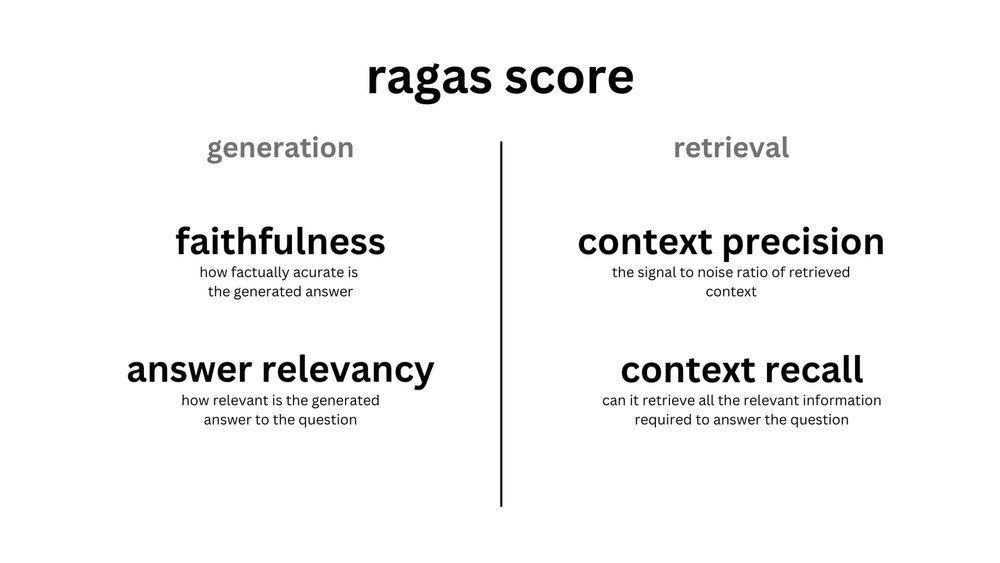

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
import pandas as pd
from typing import Optional


def data_preprocess(
    df: pd.DataFrame,
    q_col: str = "question",
    gt_col: str = "ground_truth",
    ans_col: str = "answer",
    ctx_col: Optional[str] = "contexts",
    sample_size: int = 100,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Приводит датасет к формату, совместимому с RAGAS / RAG-оценкой.

    На выходе DataFrame с колонками:
      - question: str
      - ground_truths: List[str]
      - answer: str
      - contexts: List[str]

    Параметры:
      df          — исходный DataFrame
      q_col       — имя колонки с вопросом
      gt_col      — имя колонки с правильным ответом (одна строка)
      ans_col     — имя колонки с ответом модели
      ctx_col     — имя колонки с контекстом(ами); может быть str или List[str]
      sample_size — сколько примеров оставить (для ускорения инференса)
    """
    # Берём сэмпл, если датасет большой
    if sample_size is not None and len(df) > sample_size:
        df_proc = df.sample(sample_size, random_state=random_state).copy()
    else:
        df_proc = df.copy()

    # Создаём базовые колонки
    out = pd.DataFrame()
    out["question"] = df_proc[q_col].astype(str)

    if gt_col in df_proc.columns:
        out["ground_truths"] = df_proc[gt_col].fillna("").astype(str).apply(lambda x: [x])
    else:
        out["ground_truths"] = [[] for _ in range(len(df_proc))]

    out["answer"] = df_proc[ans_col].fillna("").astype(str)

    if ctx_col is not None and ctx_col in df_proc.columns:
        def to_list(val):
            if isinstance(val, list):
                return [str(v) for v in val]
            if pd.isna(val):
                return []
            return [str(val)]
        out["contexts"] = df_proc[ctx_col].apply(to_list)
    else:
        out["contexts"] = [[] for _ in range(len(df_proc))]

    return out

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer
from typing import Tuple


def answer_relevancy(
    df_prepared: pd.DataFrame,
    embedding_model_name: str = "BAAI/bge-m3",
    normalize_embeddings: bool = True,
) -> Tuple[float, pd.DataFrame]:
    """
    Считает метрику answer_relevancy для датасета с колонками:
      - question
      - answer

    Метрика = среднее косинусное сходство между эмбеддингами вопроса и ответа.

    Возвращает:
      - scalar (float): значение метрики по всему датасету
      - DataFrame: копия с добавленной колонкой 'answer_relevancy'
    """
    model = SentenceTransformer(embedding_model_name)

    df_eval = df_prepared.copy()
    questions = df_eval["question"].fillna("").tolist()
    answers   = df_eval["answer"].fillna("").tolist()

    # Эмбеддинги
    q_emb = model.encode(questions, convert_to_numpy=True, normalize_embeddings=normalize_embeddings)
    a_emb = model.encode(answers,   convert_to_numpy=True, normalize_embeddings=normalize_embeddings)

    # Косинусное сходство
    if normalize_embeddings:
        # если нормализовали, cos = скалярное произведение
        sims = (q_emb * a_emb).sum(axis=1)
    else:
        num = (q_emb * a_emb).sum(axis=1)
        denom = np.linalg.norm(q_emb, axis=1) * np.linalg.norm(a_emb, axis=1) + 1e-9
        sims = num / denom

    df_eval["answer_relevancy"] = sims
    metric_value = float(sims.mean())

    return metric_value, df_eval

# Протестируйте ваш RAG (3 балла)

In [ ]:
def generate_question_from_row(row):
    desc = row["description"]
    name = row["Name"]
    city = row["City"]
    prompt = f"""
Сгенерируй один осмысленный вопрос на русском языке про туристический объект,
чтобы по нему можно было проверить RAG.

Название: {name}
Город: {city}
Описание: {desc[:500]}
Вопрос:
""".strip()
    return prompt

eval_df = best_rows.sample(100, random_state=42).copy()
eval_df["question"] = eval_df.apply(generate_question_from_row, axis=1)

In [ ]:
rows_for_eval = []

for _, row in eval_df.iterrows():
    q = row["question"]

    # достаём контексты
    docs = retrieve_and_rerank(
        query=q,
        vectorstore=vectorstore,
        reranker=reranker,
        k_retriever=20,
        k_rerank=5,
    )
    ctx_texts = [d.page_content for d in docs]

    # получаем ответ от RAG
    rag_answer = answer_query(
        q,
        vectorstore=vectorstore,
        reranker=reranker
    )

    rows_for_eval.append({
        "question": q,
        "answer": rag_answer,
        "contexts": ctx_texts
    })

eval_rag_df = pd.DataFrame(rows_for_eval)
eval_rag_df.head()

/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

100%|██████████| 1/1 [00:00<00:00, 17.44it/s]
/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

100%|██████████| 1/1 [00:00<00:00, 17.84it/s]
/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

100%|██████████| 1/1 [00:00<00:00, 19.96it/s]
/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

100%|██████████| 1/1 [00:00<00:00, 20.73it/s]
/usr/local/lib/python3.12/dist-packages/colbert/utils/am

,question,answer,contexts
0,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Храм Сергия Радонежского\nГород: Нижний Новгород\nОписание: Церковь Сергия Радонежского\nВопрос:","Ты — туристический гид. Отвечай только на основе контекста ниже.\nЕсли информации недостаточно, честно скажи об этом.\n\nВопрос:\nСгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Храм Сергия Радонежского\nГород: Нижний Новгород\nОписание: Церковь Сергия Радонежского\nВопрос:\n\nКонтекст:\nИсточник 1 (город: Нижний Новгород, место: Спасо-преображенский собор)\nНазвание: Спасо-преображенский собор\n\nГород: Нижний Новгород\n\nКоординаты: 56.349922, 43.872032\n\nОписание: православный храм в Нижнем Новгороде\n\nОписание изображения: arafed red and white building with a silver dome and a clock\n\nИсточник 2 (город: Нижний Новгород, место: Церковь во имя Всемилостивейшего Спаса)\nНазвание: Церковь во имя Всемилостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.31905, 44.024475\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: arafed building with a clock tower and a fence in front of it\n\nИсточник 3 (город: Нижний Новгород, место: Церковь во имя Всемирлостивейшего Спаса)\nНазвание: Церковь во имя Всемирлостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.319065, 44.024479\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: there is a large red building with domes on top of it\n\nИсточник 4 (город: Нижний Новгород, место: Храм Живоначальной Троицы)\nНазвание: Храм Живоначальной Троицы\n\nГород: Нижний Новгород\n\nКоординаты: 56.308556, 44.046577\n\nОписание: соборный храм в Нижегородском районе Нижнего Новгорода\n\nОписание изображения: there is a yellow building with two towers and a green roof\n\nИсточник 5 (город: Нижний Новгород, место: Храм Сергия Радонежского)\nНазвание: Храм Сергия Радонежского\n\nГород: Нижний Новгород\n\nКоординаты: 56.323441, 43.987236\n\nОписание: Церковь Сергия Радонежского\n\nОписание изображения: arafed white and gold building with green domes on a street","[Название: Спасо-преображенский собор\n\nГород: Нижний Новгород\n\nКоординаты: 56.349922, 43.872032\n\nОписание: православный храм в Нижнем Новгороде\n\nОписание изображения: arafed red and white building with a silver dome and a clock, Название: Церковь во имя Всемилостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.31905, 44.024475\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: arafed building with a clock tower and a fence in front of it, Название: Церковь во имя Всемирлостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.319065, 44.024479\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: there is a large red building with domes on top of it, Название: Храм Живоначальной Троицы\n\nГород: Нижний Новгород\n\nКоординаты: 56.308556, 44.046577\n\nОписание: соборный храм в Нижегородском районе Нижнего Новгорода\n\nОписание изображения: there is a yellow building with two towers and a green roof, Название: Храм Сергия Радонежского\n\nГород: Нижний Новгород\n\nКоординаты: 56.323441, 43.987236\n\nОписание: Церковь Сергия Радонежского\n\nОписание изображения: arafed white and gold building with green domes on a street]"
1,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Венера\nГород: Владимир\nОписание: \nВопрос:","Ты — туристический гид. Отвечай только на основе контекста ниже.\nЕсли информации недостаточно, честно скажи об этом.\n\nВопрос:\nСгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Венера\nГород: Владимир\nОписание: \nВопрос:\n\nКонтекст:\nИсточник 1 (город: Владимир, место: Вла

In [ ]:
df_prepared = data_preprocess(
    df=eval_rag_df,
    q_col="question",
    gt_col="ground_truth",
    ans_col="answer",
    ctx_col="contexts",
    sample_size=None,
)
df_prepared.head()

,question,ground_truths,answer,contexts
0,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Храм Сергия Радонежского\nГород: Нижний Новгород\nОписание: Церковь Сергия Радонежского\nВопрос:",[],"Ты — туристический гид. Отвечай только на основе контекста ниже.\nЕсли информации недостаточно, честно скажи об этом.\n\nВопрос:\nСгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Храм Сергия Радонежского\nГород: Нижний Новгород\nОписание: Церковь Сергия Радонежского\nВопрос:\n\nКонтекст:\nИсточник 1 (город: Нижний Новгород, место: Спасо-преображенский собор)\nНазвание: Спасо-преображенский собор\n\nГород: Нижний Новгород\n\nКоординаты: 56.349922, 43.872032\n\nОписание: православный храм в Нижнем Новгороде\n\nОписание изображения: arafed red and white building with a silver dome and a clock\n\nИсточник 2 (город: Нижний Новгород, место: Церковь во имя Всемилостивейшего Спаса)\nНазвание: Церковь во имя Всемилостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.31905, 44.024475\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: arafed building with a clock tower and a fence in front of it\n\nИсточник 3 (город: Нижний Новгород, место: Церковь во имя Всемирлостивейшего Спаса)\nНазвание: Церковь во имя Всемирлостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.319065, 44.024479\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: there is a large red building with domes on top of it\n\nИсточник 4 (город: Нижний Новгород, место: Храм Живоначальной Троицы)\nНазвание: Храм Живоначальной Троицы\n\nГород: Нижний Новгород\n\nКоординаты: 56.308556, 44.046577\n\nОписание: соборный храм в Нижегородском районе Нижнего Новгорода\n\nОписание изображения: there is a yellow building with two towers and a green roof\n\nИсточник 5 (город: Нижний Новгород, место: Храм Сергия Радонежского)\nНазвание: Храм Сергия Радонежского\n\nГород: Нижний Новгород\n\nКоординаты: 56.323441, 43.987236\n\nОписание: Церковь Сергия Радонежского\n\nОписание изображения: arafed white and gold building with green domes on a street","[Название: Спасо-преображенский собор\n\nГород: Нижний Новгород\n\nКоординаты: 56.349922, 43.872032\n\nОписание: православный храм в Нижнем Новгороде\n\nОписание изображения: arafed red and white building with a silver dome and a clock, Название: Церковь во имя Всемилостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.31905, 44.024475\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: arafed building with a clock tower and a fence in front of it, Название: Церковь во имя Всемирлостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.319065, 44.024479\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: there is a large red building with domes on top of it, Название: Храм Живоначальной Троицы\n\nГород: Нижний Новгород\n\nКоординаты: 56.308556, 44.046577\n\nОписание: соборный храм в Нижегородском районе Нижнего Новгорода\n\nОписание изображения: there is a yellow building with two towers and a green roof, Название: Храм Сергия Радонежского\n\nГород: Нижний Новгород\n\nКоординаты: 56.323441, 43.987236\n\nОписание: Церковь Сергия Радонежского\n\nОписание изображения: arafed white and gold building with green domes on a street]"
1,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Венера\nГород: Владимир\nОписание: \nВопрос:",[],"Ты — туристический гид. Отвечай только на основе контекста ниже.\nЕсли информации недостаточно, честно скажи об этом.\n\nВопрос:\nСгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Венера\nГород: Владимир\nОписание: \nВопрос:\n\nКонтекст:\nИсточник 1 (город: 

In [ ]:
metric_value, df_scored = answer_relevancy(
    df_prepared,
    embedding_model_name="BAAI/bge-m3",
)

print("Средняя answer_relevancy:", metric_value)
df_scored[["question", "answer", "answer_relevancy"]].head(3)

Средняя answer_relevancy: 0.8729254007339478


,question,answer,answer_relevancy
0,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Храм Сергия Радонежского\nГород: Нижний Новгород\nОписание: Церковь Сергия Радонежского\nВопрос:","Ты — туристический гид. Отвечай только на основе контекста ниже.\nЕсли информации недостаточно, честно скажи об этом.\n\nВопрос:\nСгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Храм Сергия Радонежского\nГород: Нижний Новгород\nОписание: Церковь Сергия Радонежского\nВопрос:\n\nКонтекст:\nИсточник 1 (город: Нижний Новгород, место: Спасо-преображенский собор)\nНазвание: Спасо-преображенский собор\n\nГород: Нижний Новгород\n\nКоординаты: 56.349922, 43.872032\n\nОписание: православный храм в Нижнем Новгороде\n\nОписание изображения: arafed red and white building with a silver dome and a clock\n\nИсточник 2 (город: Нижний Новгород, место: Церковь во имя Всемилостивейшего Спаса)\nНазвание: Церковь во имя Всемилостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.31905, 44.024475\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: arafed building with a clock tower and a fence in front of it\n\nИсточник 3 (город: Нижний Новгород, место: Церковь во имя Всемирлостивейшего Спаса)\nНазвание: Церковь во имя Всемирлостивейшего Спаса\n\nГород: Нижний Новгород\n\nКоординаты: 56.319065, 44.024479\n\nОписание: Храм Всемилостивого Спаса (Нижний Новгород)\n\nОписание изображения: there is a large red building with domes on top of it\n\nИсточник 4 (город: Нижний Новгород, место: Храм Живоначальной Троицы)\nНазвание: Храм Живоначальной Троицы\n\nГород: Нижний Новгород\n\nКоординаты: 56.308556, 44.046577\n\nОписание: соборный храм в Нижегородском районе Нижнего Новгорода\n\nОписание изображения: there is a yellow building with two towers and a green roof\n\nИсточник 5 (город: Нижний Новгород, место: Храм Сергия Радонежского)\nНазвание: Храм Сергия Радонежского\n\nГород: Нижний Новгород\n\nКоординаты: 56.323441, 43.987236\n\nОписание: Церковь Сергия Радонежского\n\nОписание изображения: arafed white and gold building with green domes on a street",0.864929
1,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Венера\nГород: Владимир\nОписание: \nВопрос:","Ты — туристический гид. Отвечай только на основе контекста ниже.\nЕсли информации недостаточно, честно скажи об этом.\n\nВопрос:\nСгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Венера\nГород: Владимир\nОписание: \nВопрос:\n\nКонтекст:\nИсточник 1 (город: Владимир, место: Владимирский государственный гуманитарный университет)\nНазвание: Владимирский государственный гуманитарный университет\n\nГород: Владимир\n\nКоординаты: 56.146389, 40.379169\n\nОписание: Владимирский государственный гуманитарный университет\n\nОписание изображения: arafed building with a sign that says russian language on it\n\nИсточник 2 (город: Владимир, место: Военно-историческая экспозиция (Золотые ворота))\nНазвание: Военно-историческая экспозиция (Золотые ворота)\n\nГород: Владимир\n\nКоординаты: 56.126881, 40.397057\n\nОписание изображения: there is a display case with a gun and other items in it\n\nИсточник 3 (город: Владимир, место: Старый Владимир)\nНазвание: Старый Владимир\n\nГород: Владимир\n\nКоординаты: 56.125145, 40.398754\n\nОписание изображения: arafed view of a city with a castle on a hill\n\nИсточник 4 (город: Владимир, место: Владимирская гвардейская ракетная Витебская Краснознамённая армия)\nНазвание: Владимирская гвардейская ракетная Витебская Краснознамённая армия\n\nГород: Владимир\n\nКоординаты: 56.131588, 40.362621\n\nОписание изображения: a close up of a poster with a flag and a map\n\nИсточник 5 (город: Владимир, место: Владимирским железнодорожникам погибш

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

Context Precision

In [ ]:
def build_context_relevance_prompt(question: str, answer: str, context: str) -> str:
    return f"""
Ты выступаешь как судья качества извлечённого контекста в системе вопрос-ответ (RAG).

Тебе даны:
- Вопрос пользователя
- Ответ модели
- Один фрагмент контекста (документа)

Задача: ответь, помогает ли ЭТОТ фрагмент контекста (целиком или частично) ответить на данный вопрос.
Если в контексте есть факты, которые используются в ответе или явно относятся к вопросу — считаем его релевантным.

Варианты ответа:
- "yes" — контекст релевантен вопросу (и/или ответу)
- "no"  — контекст не имеет отношения к вопросу или ответу

Отвечай ОДНИМ словом: yes или no.

Вопрос:
{question}

Ответ модели:
{answer}

Контекст:
{context}

Ответ (yes/no):
""".strip()

In [ ]:
import openai
openai.api_key = "sk-or-v1-796faa37e16214a7e5b1b8905b7fb1eafa36347c33c10"
openai.api_base = "https://openrouter.ai/api/v1"

def judge_llm(prompt: str) -> str:
    """LLM-судья через OpenRouter."""
    response = openai.ChatCompletion.create(
        model="qwen/qwen-2.5-7b-instruct",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    return response["choices"][0]["message"]["content"].strip()

In [ ]:
test_prompt = """
Ответь yes или no:
Является ли утверждение "Кремль находится в Москве" подтверждаемым контекстом?
Контекст: "Москва — столица России."
"""

print(judge_llm(test_prompt))

Yes


In [ ]:
import pandas as pd
from typing import Callable, Tuple, List


def context_precision(
    df_prepared: pd.DataFrame,
    llm_callable: Callable[[str], str],
    max_contexts: int = 5,
    sample_size: int = 50,
    random_state: int = 42,
) -> Tuple[float, pd.DataFrame]:
    """
    Считает retrieval-метрику context_precision в стиле RAGAS (model-as-a-judge).

    Ожидает df_prepared с колонками:
      - question: str
      - answer: str
      - contexts: List[str]

    Параметры:
      llm_callable(prompt: str) -> str  — функция вызова LLM-судьи
      max_contexts — максимум контекстов на пример (чтобы не было слишком дорого)
      sample_size  — сколько примеров взять для оценки (инференс может быть долгим!)

    Возвращает:
      - scalar (float): среднее значение context_precision по выборке
      - DataFrame: копия df_prepared с колонкой 'context_precision'
    """
    # 1. Берём сэмпл, чтобы не разориться по токенам
    if sample_size is not None and len(df_prepared) > sample_size:
        df_eval = df_prepared.sample(sample_size, random_state=random_state).copy()
    else:
        df_eval = df_prepared.copy()

    precisions: List[float] = []

    # 2. Для каждого примера оцениваем релевантность каждого контекста
    all_precisions = []
    for idx, row in df_eval.iterrows():
        question = str(row["question"])
        answer = str(row["answer"])
        contexts = row.get("contexts", [])

        # ограничим число контекстов
        if isinstance(contexts, list):
            ctxs = contexts[:max_contexts]
        else:
            # если вдруг попалась одна строка, а не список
            ctxs = [str(contexts)]

        if len(ctxs) == 0:
            all_precisions.append(0.0)
            continue

        relevant_count = 0
        total = len(ctxs)

        for ctx in ctxs:
            prompt = build_context_relevance_prompt(question, answer, ctx)
            judge_reply = llm_callable(prompt).strip().lower()

            # интерпретируем ответ
            if judge_reply.startswith("yes"):
                relevant_count += 1

        precision_i = relevant_count / total
        all_precisions.append(precision_i)

    df_eval["context_precision"] = all_precisions

    metric_value = float(sum(all_precisions) / len(all_precisions)) if all_precisions else 0.0

    return metric_value, df_eval

In [ ]:
ctx_prec_value, df_ctx_scored = context_precision(
    df_prepared=df_prepared,
    llm_callable=judge_llm,
    max_contexts=5,
    sample_size=50,
)

print("Средний context_precision:", ctx_prec_value)
df_ctx_scored[["question", "context_precision"]].head()

Средний context_precision: 0.012000000000000002


,question,context_precision
83,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Борисоглебская башня\nГород: Нижний Новгород\nОписание: круглая башня Нижегородского кремля\nВопрос:",0.0
53,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Городок Чекистов\nГород: Екатеринбург\nОписание: комплекс зданий в стиле конструктивизма\nВопрос:",0.2
70,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Бутусовский посёлок\nГород: Ярославль\nОписание: Бутусовский посёлок\nВопрос:",0.0
45,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Кирило-Афанасиевский мужской монастырь\nГород: Ярославль\nОписание: Монастырь в Ярославле\nВопрос:",0.0
44,"Сгенерируй один осмысленный вопрос на русском языке про туристический объект,\nчтобы по нему можно было проверить RAG.\n\nНазвание: Печёрский Вознесенский монастырь\nГород: Нижний Новгород\nОписание: монастырь в Нижнем Новгороде\nВопрос:",0.0


:(